In [177]:
word = open(file='./data/names.txt',mode='r').read().splitlines()
# print(word)

In [178]:
min(len(x) for x in word)

2

In [179]:
max(len(x) for x in word)

15

In [180]:
for w in word[:2]:
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

e m
m m
m a
o l
l i
i v
v i
i a


In [182]:
# for w in word:
#     chs = ['<S>'] + list(w) +['<E>']
#     for ch1, ch2 in zip(chs, chs[1:]):
#         print(ch1,ch2)

In [183]:
b = {}
for w in word:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram,0) + 1
        # print(ch1, ch2)
sorted(b.items(), key=lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [184]:
set('aaa')

{'a'}

In [185]:
import torch
N = torch.zeros(size=[28,28], dtype=torch.long)
word_str = ''.join(word)
word_str = set(word_str)
word_str = sorted(word_str)
word_list = list(word_str)
stoi = {s: i for i,s in enumerate(word_list)}
stoi['<S>'] = 26
stoi['<E>'] = 27
stoi
itos = {i: s for s, i in stoi.items()}
for w in word:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        idr = stoi[ch1]
        idc = stoi[ch2]
        N[idr,idc] += 1
        # print(ch1, ch2)

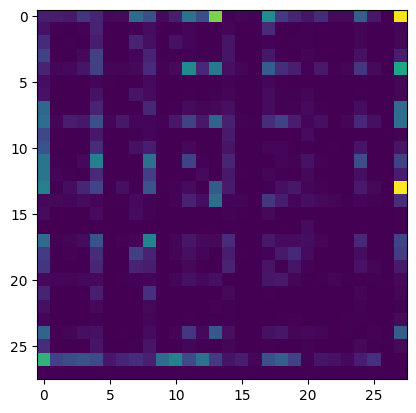

In [186]:
import matplotlib.pylab as plt
plt.imshow(N)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

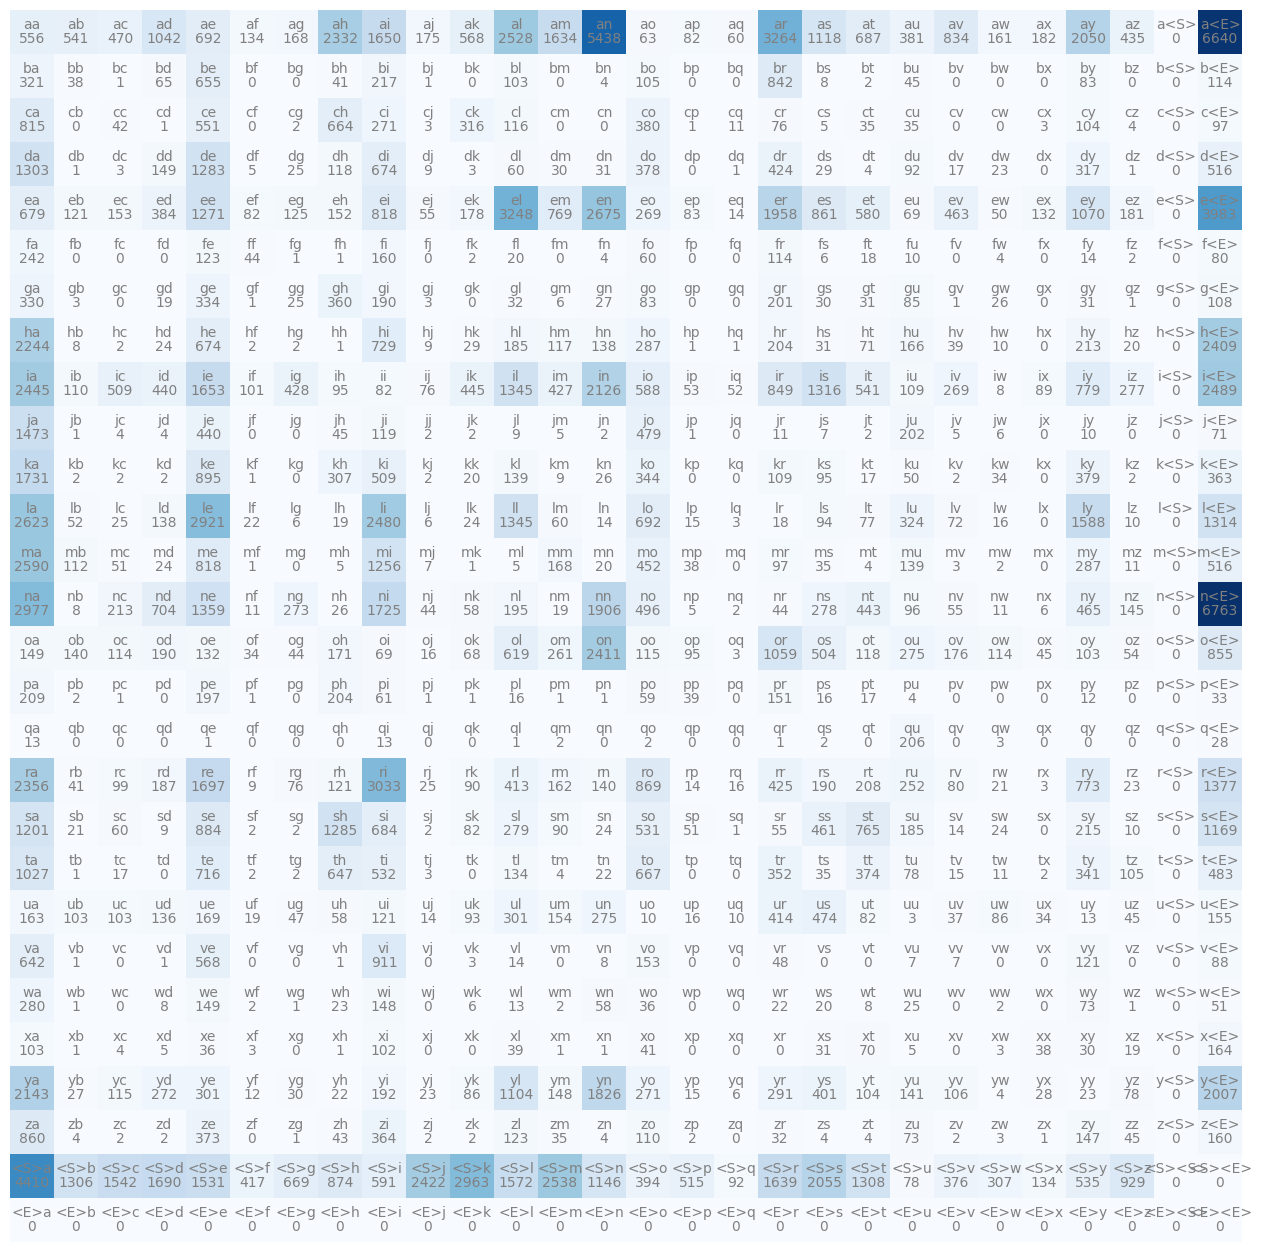

In [187]:
### 优化
plt.figure(figsize=(16,16))        # 大图
plt.imshow(N, cmap='Blues')        # 热力图，颜色深浅表示计数大小

for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]                    # 字符组合，如 'em'
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')   # 下半：显示字符对
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color='gray')  # 上半：显示计数

plt.axis('off')  # 隐藏坐标轴

In [188]:
### 进一步优化 
import torch
N = torch.zeros(size=[28,28], dtype=torch.long)
word_str = ''.join(word)
word_str = set(word_str)
word_str = sorted(word_str)
word_list = list(word_str)
stoi = {s: i+1 for i,s in enumerate(word_list)}
stoi['.'] = 0
stoi
itos = {i: s for s, i in stoi.items()}
for w in word:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idr = stoi[ch1]
        idc = stoi[ch2]
        N[idr,idc] += 1
        # print(ch1, ch2)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

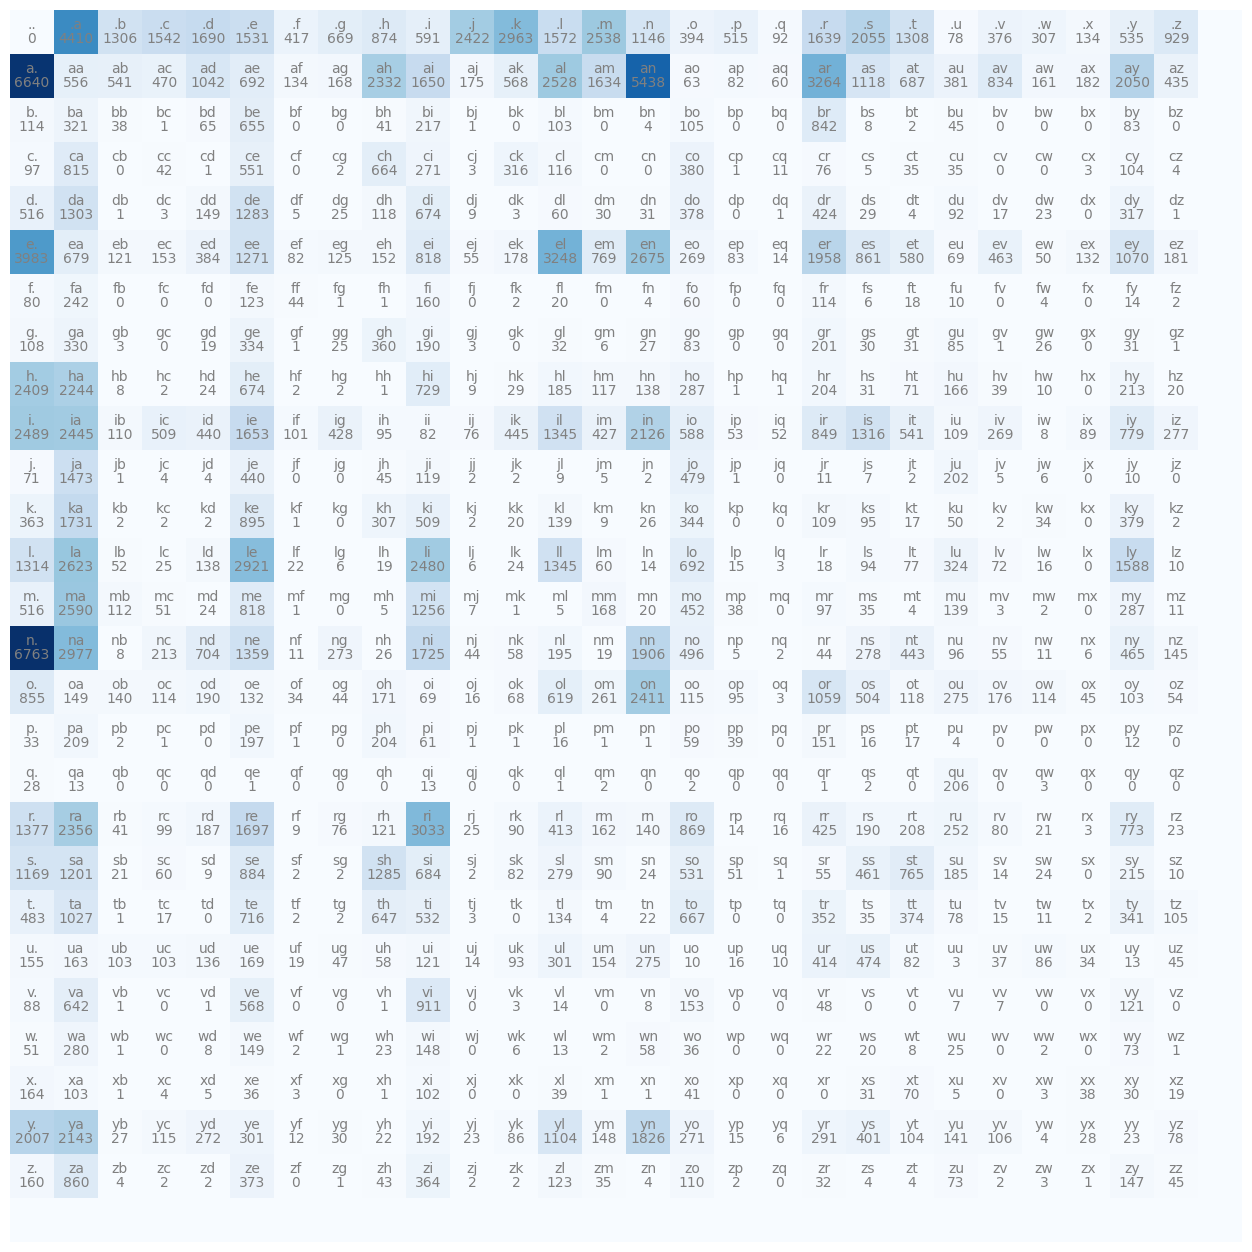

In [189]:
### 优化
plt.figure(figsize=(16,16))        # 大图
plt.imshow(N, cmap='Blues')        # 热力图，颜色深浅表示计数大小

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]                    # 字符组合，如 'em'
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')   # 下半：显示字符对
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color='gray')  # 上半：显示计数

plt.axis('off')  # 隐藏坐标轴

In [190]:
N[0,:]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929,    0])

In [191]:
p = N[0].double()/N[0].double().sum()
g = torch.Generator().manual_seed(21474883647)
ix = torch.multinomial(p, num_samples= 1, replacement=True, generator=g).item()
itos[ix]

'm'

In [192]:
### 编写循环
ix = 0
g = torch.Generator().manual_seed(21474883647)
name = []
for i in range(20):
    while True:
        p = N[ix].double() / N[ix].double().sum()
        ix = torch.multinomial(p, num_samples=1,replacement=True, generator=g).item()
        # print(itos[ix])
        name.append(itos[ix])
        if ix ==0:
            break
''.join(name)

'man.ret.pranvel.h.mynn.akhona.ja.ntorkosahvionni.da.xtrttakwi.janeenniyaha.jay.owi.ah.avima.aiyal.jabry.r.iq.lyhousovi.'

In [193]:
### 
P = (N+1) / (N + 1).sum(dim=1,keepdim=True)
ix = 0
g = torch.Generator().manual_seed(21474883647)
name = []
for i in range(20):
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1,replacement=True, generator=g).item()
        # print(itos[ix])
        name.append(itos[ix])
        if ix ==0:
            break
''.join(name)

'man.ret.pranvel.h.mynn.akhona.ja.ntorkosahvionni.da.xtrttakwi.janeenniyaha.jay.owi.ah.avima.aiyal.jabry.r.iq.lyhousovi.'

In [194]:
loglikelihood = 0
n = 0
for w in  ['mikedjd']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idr = stoi[ch1]
        idc = stoi[ch2]
        prob = P[idr,idc]
        logprob = torch.log(prob)
        loglikelihood += logprob
        n += 1
        print(f'{ch1}{ch2}, {prob: .4f}, {logprob: .4f}')
print(-loglikelihood/n)

.m,  0.0792, -2.5359
mi,  0.1885, -1.6689
ik,  0.0252, -3.6826
ke,  0.1768, -1.7328
ed,  0.0188, -3.9725
dj,  0.0018, -6.3143
jd,  0.0017, -6.3726
d.,  0.0936, -2.3688
tensor(3.5811)


In [195]:
### creat the training set
xs, ys = [], []
for w in word[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1,ch2)
        idr = stoi[ch1]
        idc = stoi[ch2]
        xs.append(idr)
        ys.append(idc)
xs = torch.tensor(xs, dtype=torch.long)        
ys = torch.tensor(ys, dtype=torch.long)
print(xs,ys)

. e
e m
m m
m a
a .
tensor([ 0,  5, 13, 13,  1]) tensor([ 5, 13, 13,  1,  0])


torch.float64


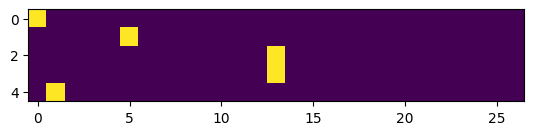

In [196]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).double()
plt.imshow(xenc)
print(xenc.dtype)

In [197]:
W = torch.randn(size=[27,27]).double()
(xenc @ W).softmax(dim=-1)

tensor([[0.0400, 0.0499, 0.0154, 0.0204, 0.0535, 0.0194, 0.0219, 0.0507, 0.0599,
         0.0187, 0.1202, 0.0651, 0.0209, 0.0685, 0.0462, 0.0184, 0.0153, 0.1387,
         0.0317, 0.0112, 0.0083, 0.0044, 0.0409, 0.0118, 0.0151, 0.0272, 0.0060],
        [0.0414, 0.0135, 0.0179, 0.0602, 0.0099, 0.0535, 0.0297, 0.0485, 0.0115,
         0.0085, 0.0968, 0.1118, 0.0911, 0.0069, 0.0348, 0.0199, 0.0311, 0.0222,
         0.0284, 0.0162, 0.0128, 0.0577, 0.0168, 0.0422, 0.0148, 0.0463, 0.0557],
        [0.0304, 0.1280, 0.0117, 0.0235, 0.0074, 0.0181, 0.0098, 0.0077, 0.0292,
         0.1185, 0.0056, 0.0561, 0.0049, 0.0223, 0.1524, 0.0038, 0.0054, 0.0369,
         0.0166, 0.1682, 0.0063, 0.0212, 0.0687, 0.0125, 0.0042, 0.0194, 0.0113],
        [0.0304, 0.1280, 0.0117, 0.0235, 0.0074, 0.0181, 0.0098, 0.0077, 0.0292,
         0.1185, 0.0056, 0.0561, 0.0049, 0.0223, 0.1524, 0.0038, 0.0054, 0.0369,
         0.0166, 0.1682, 0.0063, 0.0212, 0.0687, 0.0125, 0.0042, 0.0194, 0.0113],
        [0.0313, 0.0051,

In [198]:
logits = (xenc @ W)
counts = logits.exp()
print(counts.sum(dim=1, keepdim=True).shape)
p = counts / counts.sum(dim=1, keepdim=True)
print(p)

torch.Size([5, 1])
tensor([[0.0400, 0.0499, 0.0154, 0.0204, 0.0535, 0.0194, 0.0219, 0.0507, 0.0599,
         0.0187, 0.1202, 0.0651, 0.0209, 0.0685, 0.0462, 0.0184, 0.0153, 0.1387,
         0.0317, 0.0112, 0.0083, 0.0044, 0.0409, 0.0118, 0.0151, 0.0272, 0.0060],
        [0.0414, 0.0135, 0.0179, 0.0602, 0.0099, 0.0535, 0.0297, 0.0485, 0.0115,
         0.0085, 0.0968, 0.1118, 0.0911, 0.0069, 0.0348, 0.0199, 0.0311, 0.0222,
         0.0284, 0.0162, 0.0128, 0.0577, 0.0168, 0.0422, 0.0148, 0.0463, 0.0557],
        [0.0304, 0.1280, 0.0117, 0.0235, 0.0074, 0.0181, 0.0098, 0.0077, 0.0292,
         0.1185, 0.0056, 0.0561, 0.0049, 0.0223, 0.1524, 0.0038, 0.0054, 0.0369,
         0.0166, 0.1682, 0.0063, 0.0212, 0.0687, 0.0125, 0.0042, 0.0194, 0.0113],
        [0.0304, 0.1280, 0.0117, 0.0235, 0.0074, 0.0181, 0.0098, 0.0077, 0.0292,
         0.1185, 0.0056, 0.0561, 0.0049, 0.0223, 0.1524, 0.0038, 0.0054, 0.0369,
         0.0166, 0.1682, 0.0063, 0.0212, 0.0687, 0.0125, 0.0042, 0.0194, 0.0113],
     

In [199]:
### ====================> optimization !!!
xs

tensor([ 0,  5, 13, 13,  1])

In [200]:
ys

tensor([ 5, 13, 13,  1,  0])

In [205]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn(size=[27,27], generator=g, requires_grad= True) #### 和micrograd 一样会建立计算图
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(dim= -1, keepdim=True)

In [ ]:
loss = - probs[torch.arange(0,5), ys].log().mean()
print(loss)
W.grad = None
loss.backward() ### 反向传播
W.grad
### 
W.data -= 0.1 * W.grad

tensor(3.7392, grad_fn=<NegBackward0>)


In [ ]:
W.grad.shape

torch.Size([27, 27])

In [203]:
### ====================> optimization !!! Now complete it !!!
xs, ys = [], []
for w in word:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idr = stoi[ch1]
        idc = stoi[ch2]
        xs.append(idr)
        ys.append(idc)
xs = torch.tensor(xs, dtype=torch.long)
ys = torch.tensor(ys, dtype=torch.long)
num = xs.nelement()
print(num)
g = torch.Generator().manual_seed(2147483647)
W = torch.randn(size = [27,27], generator=g, requires_grad= True)

228146


In [204]:
from tqdm import tqdm
for i in tqdm(range(100)):
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = (xenc @ W)
    counts = logits.exp()
    probs = counts / counts.sum(dim= -1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean()
    if i % 100 == 0:
        print(loss.item())
    W.grad = None
    loss.backward()
    W.data -= 50 * W.grad
print(loss.item())

  3%|▎         | 3/100 [00:00<00:03, 29.43it/s]

3.758953809738159


100%|██████████| 100/100 [00:01<00:00, 75.20it/s]

2.4728763103485107
